In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv'

# DataFrame으로 열기 df = data frame
df2 = pd.read_csv(path)

df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
y = df2['BMI']
y.value_counts()
y

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [4]:
X=df2.drop('BMI',axis=1)
X.head()
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,0.627,50,1
1,1,85,66,29,0,0.351,31,0
2,8,183,64,0,0,0.672,32,1
3,1,89,66,23,94,0.167,21,0
4,0,137,40,35,168,2.288,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,0.171,63,0
764,2,122,70,27,0,0.340,27,0
765,5,121,72,23,112,0.245,30,0
766,1,126,60,0,0,0.349,47,1


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [8]:
# 1. 모델 생성 및 학습
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()       # 선형 회귀 알고리즘을 사용하기 위한 모델 객체를 생성.
model.fit(X_train, y_train)      # 학습 데이터(X_train)와 정답(y_train)을 넣어 모델을 학습.
ly_preds = model.predict(X_test) # 학습된 모델에 테스트 데이터(X_test)를 넣어 BMI 수치를 예측.

# 2. 첫 번째 방식: 사이킷런(sklearn) 라이브러리 사용
# mean_squared_error 함수를 호출하여 예측값과 실제값 사이의 오차를 계산.
print('평균제곱근오차(sklearn):', mean_squared_error(ly_preds, y_test))

# 3. 두 번째 방식: NumPy를 활용한 직접 구현
# 행렬 연산에 최적화된 NumPy 라이브러리를 사용하여 수식을 구현.
def mse_np(actual, predicted):
    # (실제값 - 예측값)의 제곱들을 구한 뒤, 그 전체의 평균(mean)을 구함.
    # np.array()로 변환하여 벡터 연산이 가능하게 만듦.
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차(numpy):', mse_np(ly_preds, y_test))

# 4. 세 번째 방식: 순수 파이썬(Python) 반복문을 활용한 구현
# 외부 라이브러리 없이 기본 문법만으로 MSE의 정의를 그대로 코드로 옮긴 예시.
def mse(actual, predicted):
    # zip을 사용하여 실제값(a)과 예측값(p)을 하나씩 꺼내 오차의 제곱을 구하고 모두 더함(sum).
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))

    # 오차 제곱의 총합을 데이터의 개수(len)로 나누어 평균값을 구함.
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차(pure python):', mse(ly_preds, y_test))

평균제곱근오차 52.23558099742443
평균제곱근오차 52.23558099742443
평균제곱근오차 52.23558099742445


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_209/3032514812.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


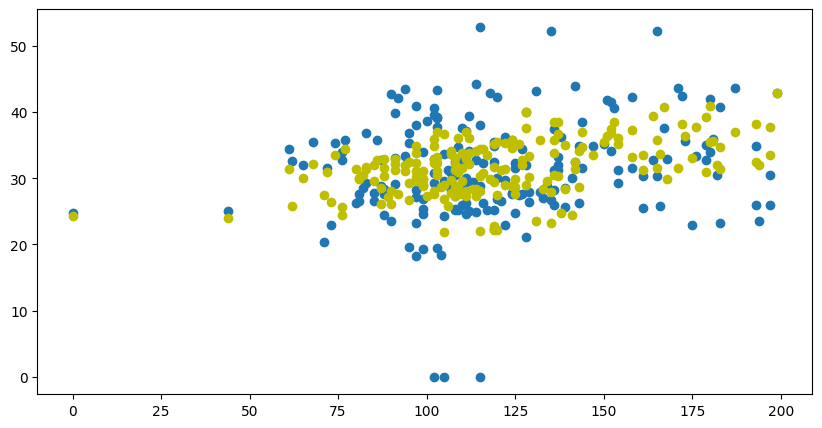

In [16]:
# 예측값과 실제 값 차이를 산접도로 표시, 노란색 예측

# 그래프의 크기를 가로 10인치, 세로 5인치로 설정.
plt.figure(figsize=(10, 5))

# 실제값(정답) 시각화:
# x축은 테스트 데이터의 'Glucose', y축은 실제 BMI 값('y_test')으로 점을 찍음.
# 기본 색상(파란색)으로 표시되며, 범례 이름을 'y_test'로 지정.
plt.scatter(X_test['Glucose'], y_test, label='y_test')

# 예측값 시각화:
# x축은 동일하게 'Glucose'를 사용하고, y축은 모델이 예측한 BMI 값('ly_preds')을 사용.
# c='y' 옵션을 주어 점의 색상을 노란색(Yellow)으로 표시하며, 범례를 'ly_preds'로 지정.
plt.scatter(X_test['Glucose'], ly_preds, c='y', label='ly_preds')

# 그래프에 범례(label)를 표시하여 어떤 점이 실제값이고 예측값인지 구분.
plt.legend()

# 완성된 그래프를 화면에 출력.
plt.show()

In [17]:
# 1. 의사결정나무 회귀 모델 불러오기 및 생성
from sklearn.tree import DecisionTreeRegressor

# DecisionTreeRegressor 객체를 생성.
# 분류 모델(Classifier)이 아닌 수치를 예측하는 '회귀(Regressor)' 모델.
model = DecisionTreeRegressor()

# 2. 모델 학습
# 학습 데이터(X_train)의 특징들과 정답(y_train, BMI 수치) 간의 관계를
# 나무 구조(Tree structure) 형태의 규칙으로 학습.
model.fit(X_train, y_train)

# 3. 성능 평가 지표 불러오기
from sklearn.metrics import mean_squared_error

# 4. 예측 수행
# 학습 과정에서 보지 못한 테스트 데이터(X_test)를 넣어 BMI 수치를 예측.
dy_preds = model.predict(X_test)

# 5. 결과 출력 (MSE)
# 실제 BMI 값(y_test)과 의사결정나무가 예측한 값(dy_preds) 사이의 평균 제곱 오차를 구함.
print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

평균제곱근오차 77.31499999999998


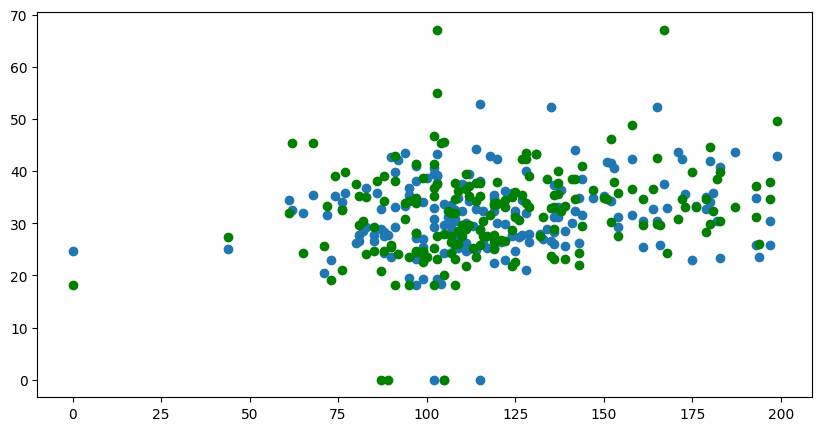

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], dy_preds, c='g', label='dy_preds')
plt.show()

In [19]:
# 1. 랜덤 포레스트 회귀 모델 불러오기 및 생성
from sklearn.ensemble import RandomForestRegressor

# RandomForestRegressor 객체를 생성.
# 수많은 의사결정나무(기본값 100개)를 만들어 그들의 평균 예측치를 사용하는 앙상블 모델.
model = RandomForestRegressor()

# 2. 모델 학습
# 학습 데이터(X_train)와 정답(y_train)을 넣어 모델을 학습.
# 내부적으로 여러 개의 나무가 서로 다른 데이터 샘플과 특징들을 학습하며 집단지성을 구축.
model.fit(X_train, y_train)

# 3. 성능 평가 지표 불러오기
from sklearn.metrics import mean_squared_error

# 4. 예측 수행
# 테스트 데이터(X_test)를 넣어 BMI 수치를 예측.
# 100개의 나무가 각각 예측한 값들의 평균값이 최종 예측값(ry_preds)이 됨.
ry_preds = model.predict(X_test)

# 5. 결과 출력 (MSE)
# 실제값(y_test)과 랜덤 포레스트의 예측값(ry_preds) 사이의 평균 제곱 오차를 구함.
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

평균제곱근오차 47.895254854166694


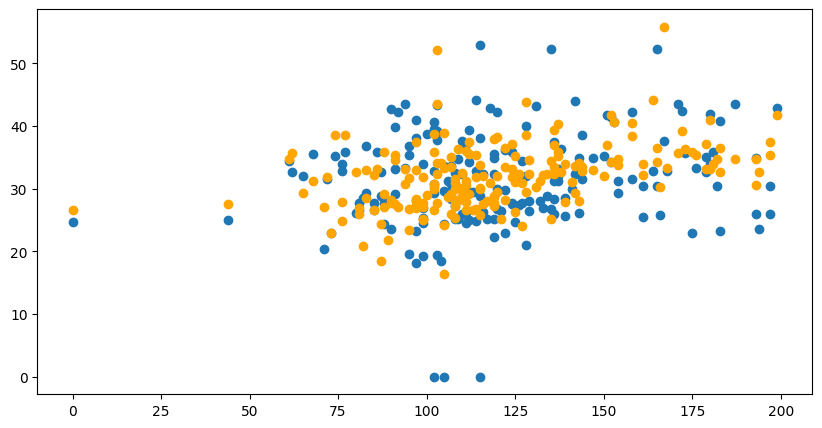

In [20]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], ry_preds, c='orange', label='ry_preds')

plt.show()